# Data Visualization
Explore the histopathology dataset: label/center distributions, sample images, and pixel statistics.

This notebook is for **exploration only**, no training happens here.

In [1]:
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from dlmi.dataset import load_h5_metadata
from dlmi.utils import set_seed

set_seed(0)

In [2]:
TRAIN_PATH = "../data/train.h5"
VAL_PATH = "../data/val.h5"
TEST_PATH = "../data/test.h5"

## 1. Dataset overview
Load metadata (IDs, labels, centers) and examine class/center distributions.

In [3]:
train_ids, train_labels, train_centers = load_h5_metadata(TRAIN_PATH)
val_ids, val_labels, val_centers = load_h5_metadata(VAL_PATH)

train_df = pd.DataFrame(
    {"id": train_ids, "label": train_labels, "center": train_centers, "split": "train"}
)
val_df = pd.DataFrame(
    {"id": val_ids, "label": val_labels, "center": val_centers, "split": "val"}
)
df = pd.concat([train_df, val_df], ignore_index=True)

print(f"Train samples: {len(train_df)}, Val samples: {len(val_df)}")
df.head()

Train samples: 100000, Val samples: 34904


,id,label,center,split
0,0,0,3,train
1,1,0,3,train
2,10,1,4,train
3,100,1,3,train
4,1000,0,3,train


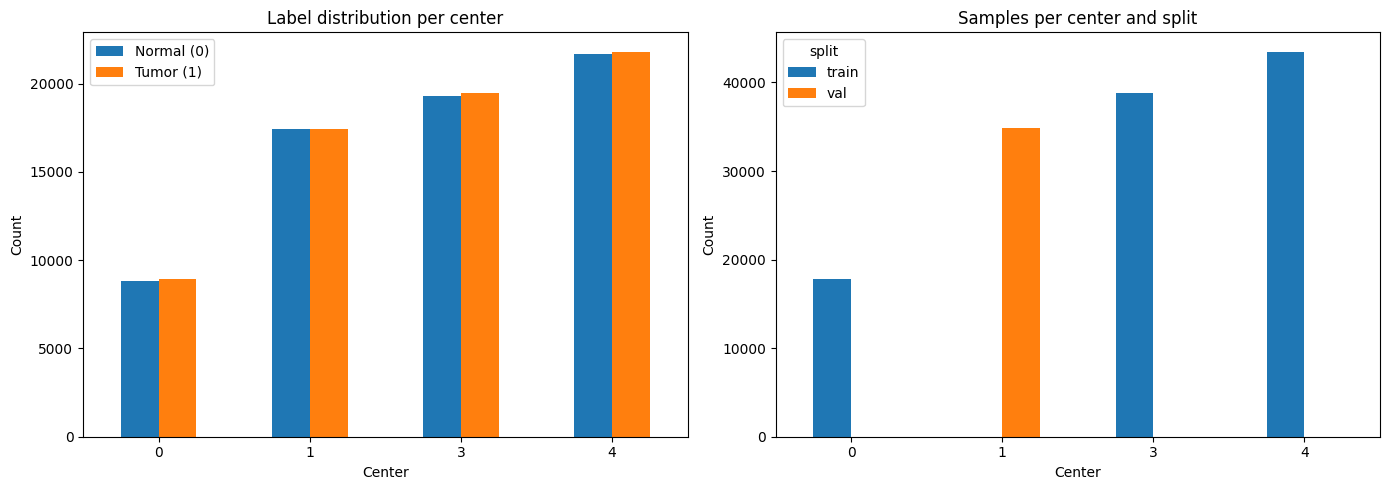

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Label distribution per center
ct = pd.crosstab(df["center"], df["label"])
ct.plot.bar(ax=axes[0], rot=0)
axes[0].set_title("Label distribution per center")
axes[0].set_xlabel("Center")
axes[0].set_ylabel("Count")
axes[0].legend(["Normal (0)", "Tumor (1)"])

# Samples per split/center
ct2 = pd.crosstab(df["center"], df["split"])
ct2.plot.bar(ax=axes[1], rot=0)
axes[1].set_title("Samples per center and split")
axes[1].set_xlabel("Center")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

## 2. Sample images from each center and class
Visualize the distribution shift across centers.

In [6]:
# Collect one sample per (center, label)
train_samples = {0: {0: None, 1: None}, 3: {0: None, 1: None}, 4: {0: None, 1: None}}
val_samples = {1: {0: None, 1: None}}

for samples, path in [(train_samples, TRAIN_PATH), (val_samples, VAL_PATH)]:
    with h5py.File(path, "r") as hdf:
        for img_idx in hdf.keys():
            label = int(np.array(hdf[img_idx]["label"]))
            center = int(np.array(hdf[img_idx]["metadata"])[0])
            if center in samples and samples[center][label] is None:
                samples[center][label] = np.array(hdf[img_idx]["img"])
            if all(all(v is not None for v in d.values()) for d in samples.values()):
                break

all_samples = {**train_samples, **val_samples}

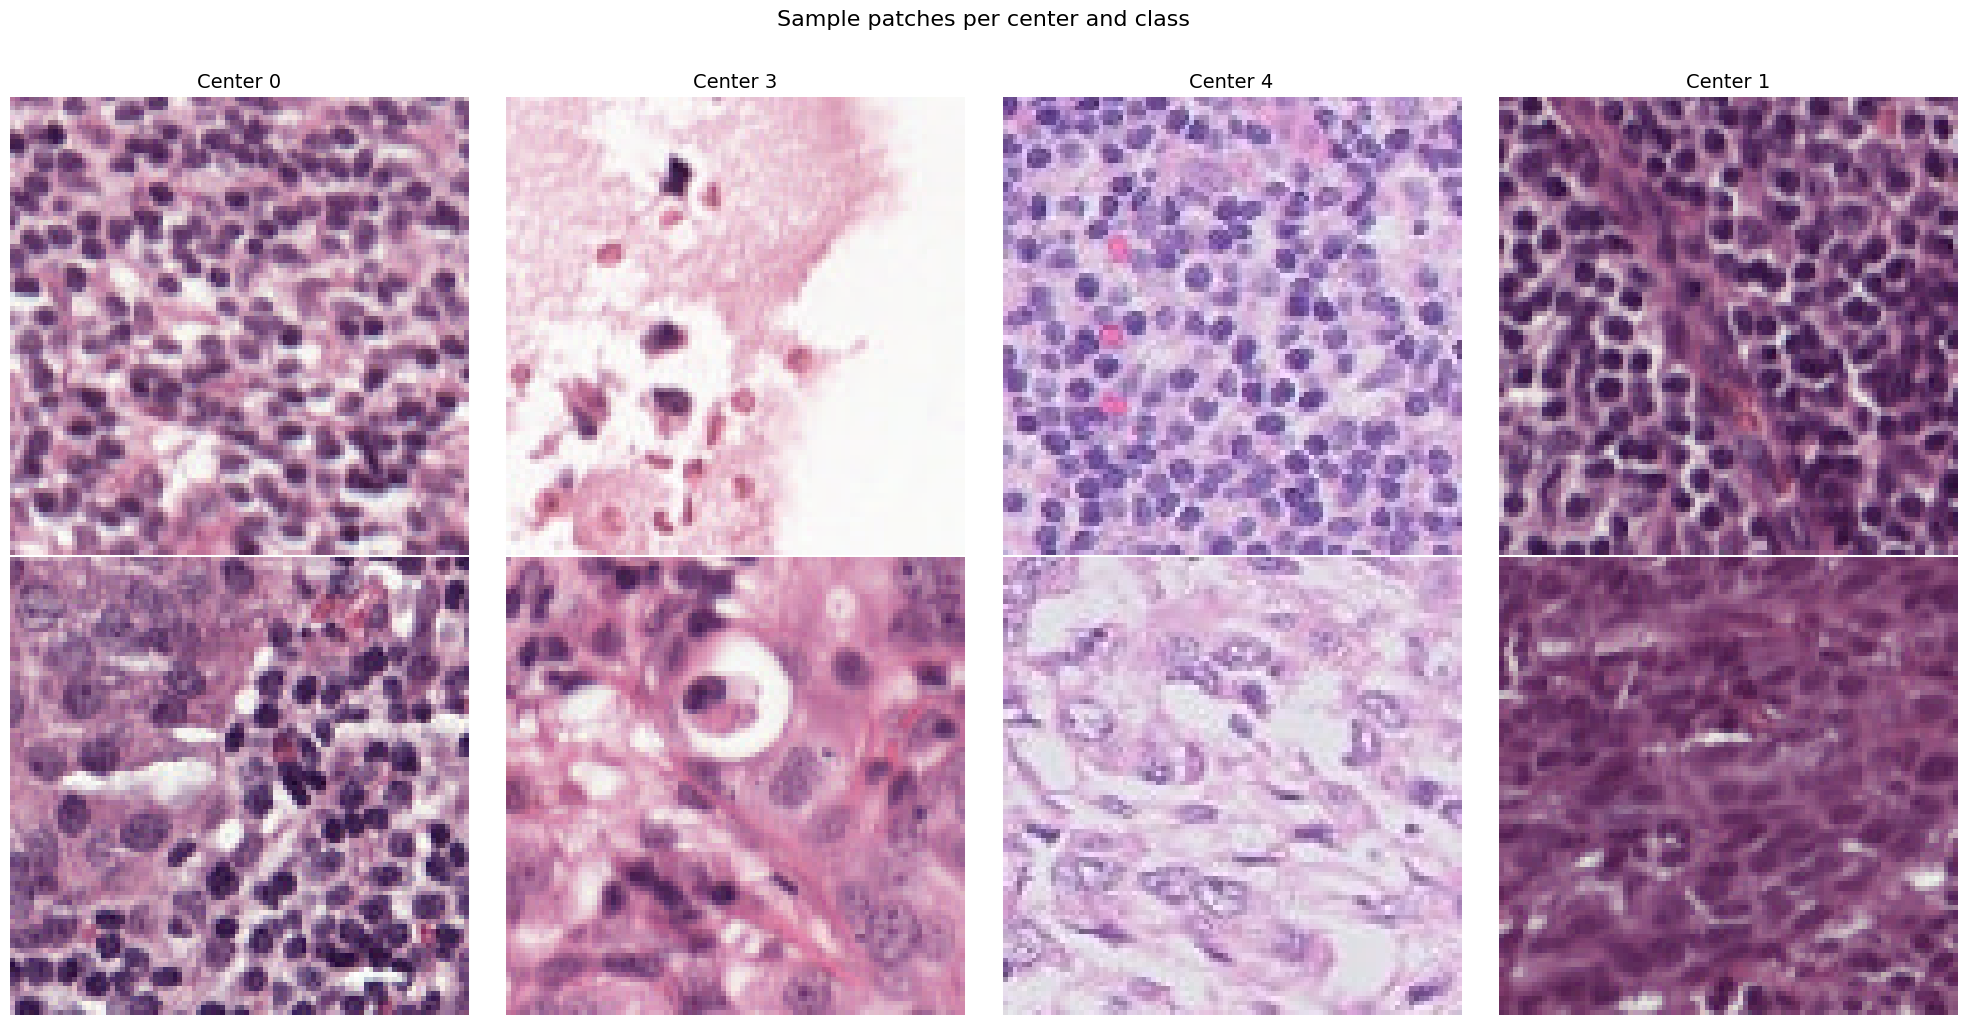

In [7]:
centers = list(all_samples.keys())
fig, axs = plt.subplots(2, len(centers), figsize=(5 * len(centers), 10))
for col, center in enumerate(centers):
    for row, label in enumerate([0, 1]):
        img = np.moveaxis(all_samples[center][label], 0, -1).astype(np.float32)
        # Normalize to [0,1] if needed
        if img.max() > 1.0:
            img = img / 255.0
        axs[row, col].imshow(img)
        axs[row, col].axis("off")
        if row == 0:
            axs[row, col].set_title(f"Center {center}", fontsize=14)
    axs[0, col].set_ylabel("Normal", fontsize=12)
    axs[1, col].set_ylabel("Tumor", fontsize=12)
plt.suptitle("Sample patches per center and class", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

## 3. Pixel statistics per center
Compute per-channel mean and standard deviation to quantify the distribution shift.

In [8]:
def compute_pixel_stats(h5_path, max_samples=500):
    """Compute per-channel mean and std from a random subset of images."""
    pixel_sums = np.zeros(3)
    pixel_sq_sums = np.zeros(3)
    count = 0
    with h5py.File(h5_path, "r") as hdf:
        keys = list(hdf.keys())
        np.random.shuffle(keys)
        for k in keys[:max_samples]:
            img = np.array(hdf[k]["img"]).astype(np.float64)  # (C, H, W)
            pixel_sums += img.mean(axis=(1, 2))
            pixel_sq_sums += (img**2).mean(axis=(1, 2))
            count += 1
    mean = pixel_sums / count
    std = np.sqrt(pixel_sq_sums / count - mean**2)
    return mean, std


stats = {}
for name, path in [("Train", TRAIN_PATH), ("Val", VAL_PATH)]:
    mean, std = compute_pixel_stats(path)
    stats[name] = {
        "R_mean": mean[0],
        "G_mean": mean[1],
        "B_mean": mean[2],
        "R_std": std[0],
        "G_std": std[1],
        "B_std": std[2],
    }

stats_df = pd.DataFrame(stats).T
stats_df.round(2)

,R_mean,G_mean,B_mean,R_std,G_std,B_std
Train,0.74,0.59,0.72,0.18,0.21,0.17
Val,0.61,0.46,0.59,0.19,0.22,0.18
